# S03.3 – Метрики как инструмент управления риском ошибок-–

Цель: понять, почему одной accuracy недостаточно, и как менять поведение модели через порог (threshold).

## Что вы освоите
- Понимать, чем опасна accuracy при дисбалансе классов
- Отличать precision/recall и связывать их с риском FP/FN
- Понимать идею порога: один и тот же скоринг → разные решения
- Уметь строить простую кривую precision/recall по порогу

## Важные оговорки
- Мы не изучаем теорию моделей. Мы рассматриваем метрики и порог как инженерную ручку.
- Чтобы работать с порогом, нам нужен скоринг (вероятность или "балл").

---


## Среда, воспроизводимость и стиль эксперимента

Перед кодом – несколько правил, которые будут повторяться во всех ноутбуках:

1) **Воспроизводимость**: фиксируем `random_state` / seed.  
2) **Разделение данных**: test‑часть – это *священная зона*. Мы смотрим на неё только в конце.  
3) **Всё, что "обучается" (`.fit`)** должно видеть только train‑данные (иначе легко получить утечки).  
4) **Sanity‑checks**: после каждого шага проверяем, что получился ожидаемый результат (формы, распределения, пересечения и т.д.).


In [1]:
# Импорты: минимальный, но достаточный набор
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Для красивых картинок (простая визуализация)
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)


numpy: 2.0.2
pandas: 2.2.2


## Общие функции (оценка моделей и печать метрик)

Чтобы не копировать одно и то же вручную, заведём пару функций.

Важно: эти функции *ничего не делают магически*. Мы специально пишем их максимально прозрачно,
чтобы вы видели, какие именно метрики считаются и на каких данных.


In [2]:
def summarize_binary_metrics(y_true, y_pred, *, positive_label=1):
    """Считает базовые метрики бинарной классификации.

    Мы считаем:
    - accuracy: доля верных ответов
    - precision: насколько "чистые" наши позитивные предсказания
    - recall: насколько хорошо мы находим позитивный класс
    - f1: гармоническое среднее precision и recall

    Почему это важно: в задачах безопасности цена FP и FN может быть разной.
    """
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
    }

def print_confusion(y_true, y_pred, labels=(0,1)):
    """Печать матрицы ошибок и пояснения, что есть что."""
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    df = pd.DataFrame(cm, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
    display(df)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN={tn} (верно: 0), FP={fp} (ложная тревога), FN={fn} (пропуск), TP={tp} (верно: 1)")
    return cm

def evaluate_model(model, X_train, y_train, X_test, y_test, *, model_name="model"):
    """Обучает модель на train и оценивает на test. Возвращает словарь метрик."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = summarize_binary_metrics(y_test, y_pred)
    print(f"=== {model_name} ===")
    print(metrics)
    print("Confusion matrix:")
    _ = print_confusion(y_test, y_pred)
    return metrics


## Шаг 1. Сделаем искусственный дисбаланс

В реальных задачах безопасности часто редкий класс – это "инцидент", "атака", "аномалия".
Если таких объектов мало, accuracy может быть высокой даже у бессмысленного классификатора.

Мы сгенерируем синтетический датасет `make_classification` с сильным дисбалансом.


In [3]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=6000,
    n_features=20,
    n_informative=4,
    n_redundant=2,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],   # 5% позитивного класса
    flip_y=0.01,
    random_state=RANDOM_STATE
)

X = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
y = pd.Series(y, name="y")

print("Class balance overall:")
display(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)


Class balance overall:


,proportion
y,
0,0.945
1,0.055


## Шаг 2. Baseline Dummy и иллюзия accuracy

Сначала посмотрим на Dummy. Часто при дисбалансе `most_frequent` даёт большую accuracy –
и это *не успех*, а иллюзия: модель просто никогда не находит редкий класс.


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_recall_fscore_support

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0)
}
print(metrics)
print_confusion(y_test, y_pred)


{'accuracy': 0.9453333333333334, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


,pred_0,pred_1
true_0,1418,0
true_1,82,0


TN=1418 (верно: 0), FP=0 (ложная тревога), FN=82 (пропуск), TP=0 (верно: 1)


array([[1418,    0],
       [  82,    0]])

Ожидаемое наблюдение:
- accuracy будет близка к 0.95 (потому что 95% – нулевой класс),
- recall по позитивному классу будет ~0 (инциденты не находятся),
- значит такая "модель" не годится, если для нас важны пропуски (FN).

Теперь нам нужен классификатор, который выдаёт **скоринг** (например, вероятность),
чтобы мы могли менять порог.


## Шаг 3. Простой скоринговый классификатор как "чёрный ящик"

Мы возьмём `DecisionTreeClassifier` небольшой глубины. Не как "тема деревьев", а как объект,
который умеет:
- `.fit()`,
- `.predict_proba()` – выдаёт вероятности классов.

Это нужно только для демонстрации порога.


In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]   # вероятность позитивного класса
print("proba shape:", proba.shape, "min/max:", proba.min(), proba.max())


proba shape: (1500,) min/max: 0.0 1.0


## Шаг 4. Порог (threshold) и компромисс precision/recall

Правило принятия решения:
- если `proba >= threshold` → предсказываем 1,
- иначе 0.

Если увеличить threshold:
- меньше ложных тревог (FP) → precision растёт,
- но больше пропусков (FN) → recall падает.

Если уменьшить threshold:
- recall растёт,
- но могут вырасти FP (precision падает).

Сейчас построим кривые по порогам.


In [6]:
def predict_by_threshold(proba, threshold):
    return (proba >= threshold).astype(int)

thresholds = np.linspace(0.0, 1.0, 101)
rows = []
for t in thresholds:
    y_hat = predict_by_threshold(proba, t)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_hat),
        "precision": precision_score(y_test, y_hat, zero_division=0),
        "recall": recall_score(y_test, y_hat, zero_division=0),
        "f1": f1_score(y_test, y_hat, zero_division=0),
    })

curve = pd.DataFrame(rows)
display(curve.head())


,threshold,accuracy,precision,recall,f1
0,0.00,0.054667,0.054667,1.000000,0.103666
1,0.01,0.055333,0.054703,1.000000,0.103732
2,0.02,0.088667,0.055978,0.987805,0.105952
3,0.03,0.088667,0.055978,0.987805,0.105952
4,0.04,0.891333,0.231788,0.426829,0.300429


### Графики: как метрики меняются с порогом

Мы не оптимизируем порог "в прод". Мы учимся понимать поведение системы.


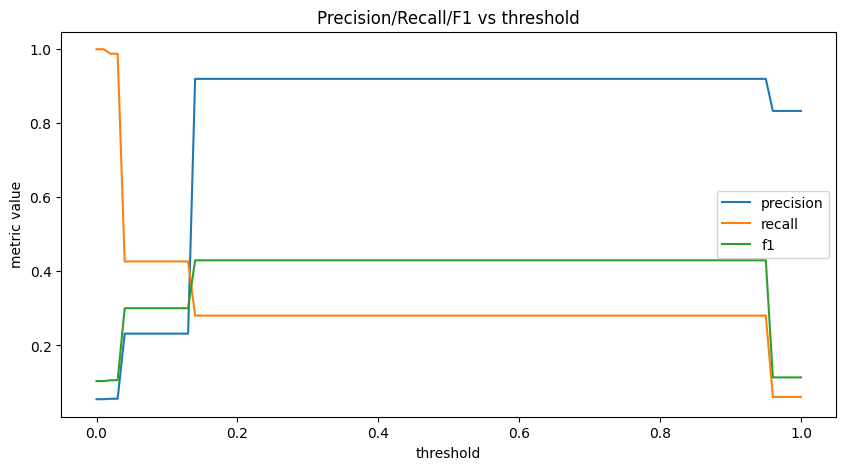

In [7]:
plt.figure(figsize=(10,5))
plt.plot(curve["threshold"], curve["precision"], label="precision")
plt.plot(curve["threshold"], curve["recall"], label="recall")
plt.plot(curve["threshold"], curve["f1"], label="f1")
plt.xlabel("threshold")
plt.ylabel("metric value")
plt.title("Precision/Recall/F1 vs threshold")
plt.legend()
plt.show()


## Шаг 5. Выбор порога под риск

Инженерная формулировка:
- если пропуск инцидента (FN) очень дорогой → держим recall выше;
- если ложная тревога (FP) очень дорогая → держим precision выше.

Покажем 2 порога и сравним матрицы ошибок.


In [8]:
for t in [0.2, 0.8]:
    y_hat = predict_by_threshold(proba, t)
    print(f"--- threshold={t} ---")
    print(summarize_binary_metrics(y_test, y_hat))
    print_confusion(y_test, y_hat)


--- threshold=0.2 ---
{'accuracy': 0.9593333333333334, 'precision': 0.92, 'recall': 0.2804878048780488, 'f1': 0.42990654205607476}


,pred_0,pred_1
true_0,1416,2
true_1,59,23


TN=1416 (верно: 0), FP=2 (ложная тревога), FN=59 (пропуск), TP=23 (верно: 1)
--- threshold=0.8 ---
{'accuracy': 0.9593333333333334, 'precision': 0.92, 'recall': 0.2804878048780488, 'f1': 0.42990654205607476}


,pred_0,pred_1
true_0,1416,2
true_1,59,23


TN=1416 (верно: 0), FP=2 (ложная тревога), FN=59 (пропуск), TP=23 (верно: 1)


## Мини-итог S03.2

1) Accuracy при дисбалансе часто вводит в заблуждение.  
2) Precision/Recall описывают разные риски (FP vs FN).  
3) Порог – инженерная ручка: один и тот же скоринг может дать разное поведение системы.  

Дальше (в S05/S06) вы будете сравнивать модели **на одном протоколе**, но уже осознанно выбирая метрики.
